In [6]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from portfolio import portfolio_returns, portfolio_growth, portfolio_metrics, portfolio_growth_df, compare_portfolios, compare_portfolio_metrics

from features import (
    simple_returns,
    log_returns,
    annualized_return,
    annualized_volatility,
    sharpe_ratio
)

In [7]:
prices = pd.read_csv(
    "../data/raw/prices.csv",
    parse_dates=["Date"],
    index_col="Date"
)

prices.head()

,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-02,40.304176,59.450500,53.258095,78.870354,21.368668
2018-01-03,40.297157,60.209999,54.166725,79.237411,21.150000
2018-01-04,40.484333,60.479500,54.377140,79.934814,20.974667
2018-01-05,40.945255,61.457001,55.098186,80.925865,21.105333
2018-01-08,40.793175,62.343498,55.292725,81.008423,22.427334


In [8]:
returns = simple_returns(prices)
returns.head()

,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-03,-0.000174,0.012775,0.017061,0.004654,-0.010233
2018-01-04,0.004645,0.004476,0.003885,0.008801,-0.008290
2018-01-05,0.011385,0.016163,0.013260,0.012398,0.006230
2018-01-08,-0.003714,0.014425,0.003531,0.001020,0.062638
2018-01-09,-0.000114,0.004676,-0.001274,-0.000679,-0.008085


In [9]:
log_rets = log_returns(prices)
log_rets.head()

,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-02,3.720964,4.101825,3.993752,4.380405,3.107661
2018-01-03,3.720794,4.114311,4.010360,4.384990,3.097837
2018-01-04,3.725316,4.118704,4.014167,4.393644,3.089890
2018-01-05,3.736365,4.134478,4.027103,4.405815,3.095819
2018-01-08,3.732733,4.148572,4.030565,4.406822,3.153903


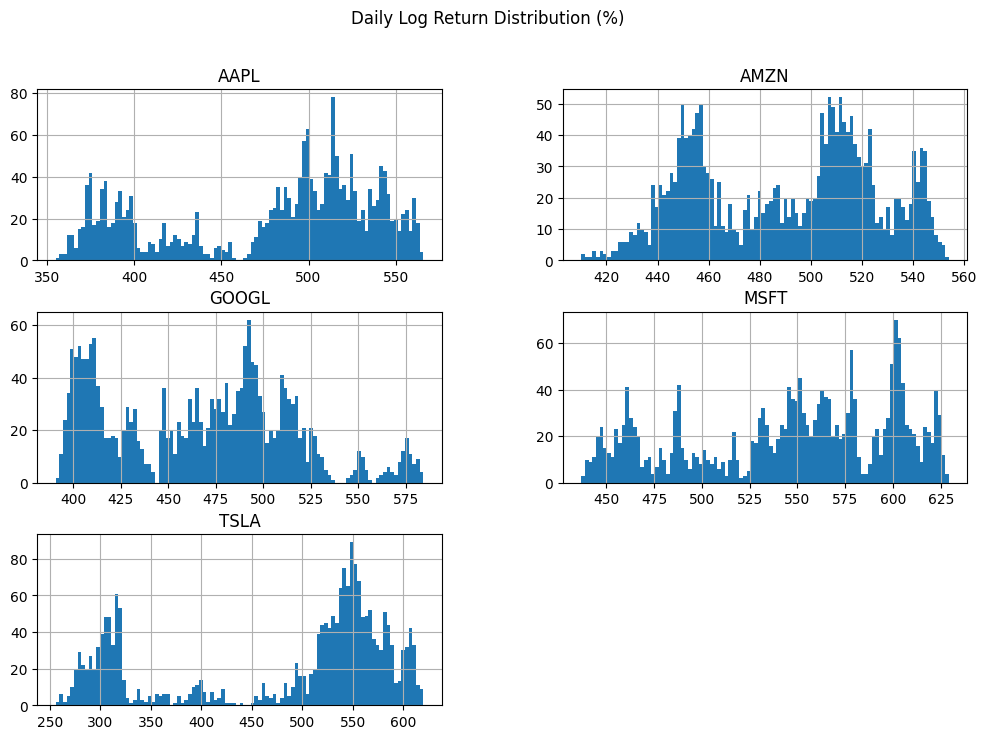

In [10]:
# Compute log returns from prices
log_returns = log_returns(prices)

# Convert to percentage to make the x-axis easier to read
log_returns_pct = log_returns * 100

# Plot distribution
log_returns_pct.hist(bins=100, figsize=(12,8))

plt.suptitle("Daily Log Return Distribution (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

In [11]:
metrics = pd.DataFrame({
    "Annual Return": annualized_return(returns),
    "Annual Volatility": annualized_volatility(returns),
    "Sharpe": sharpe_ratio(returns)
})

metrics

,Annual Return,Annual Volatility,Sharpe
AAPL,0.274666,0.307053,0.894523
AMZN,0.215706,0.343610,0.627762
GOOGL,0.259034,0.308170,0.840554
MSFT,0.242767,0.285514,0.850282
TSLA,0.557281,0.632053,0.881700


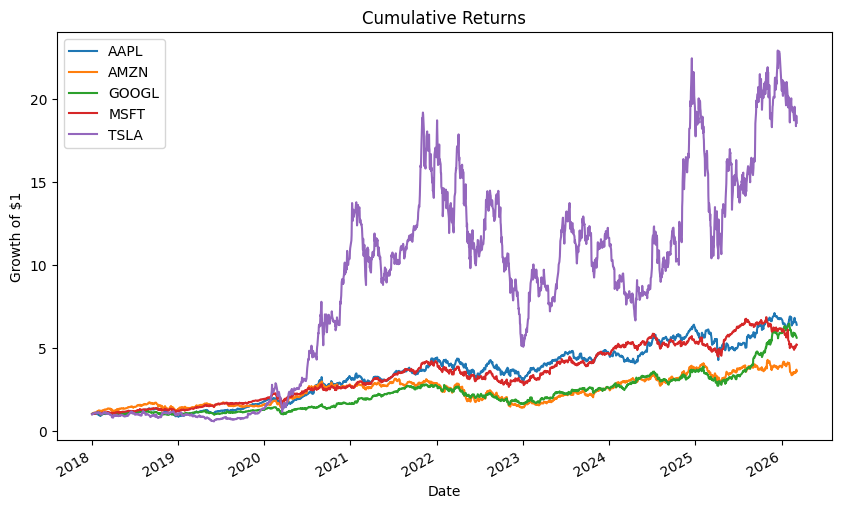

In [12]:
cum_returns = (1 + returns).cumprod()

cum_returns.plot(figsize=(10,6))
plt.title("Cumulative Returns")
plt.ylabel("Growth of $1")
plt.show()

In [13]:
weights = {
    "AAPL": 0.3,
    "MSFT": 0.3,
    "GOOGL": 0.2,
    "AMZN": 0.1,
    "TSLA": 0.1,
}

In [14]:
port_rets = portfolio_returns(returns, weights)
port_rets.head()

Date
2018-01-03    0.005010
2018-01-04    0.004429
2018-01-05    0.012026
2018-01-08    0.007604
2018-01-09   -0.000834
dtype: float64

In [15]:
port_metrics = portfolio_metrics(port_rets)
port_metrics

Annual Return        0.284335
Annual Volatility    0.274056
Sharpe               1.037509
Max Drawdown        -0.400513
dtype: float64

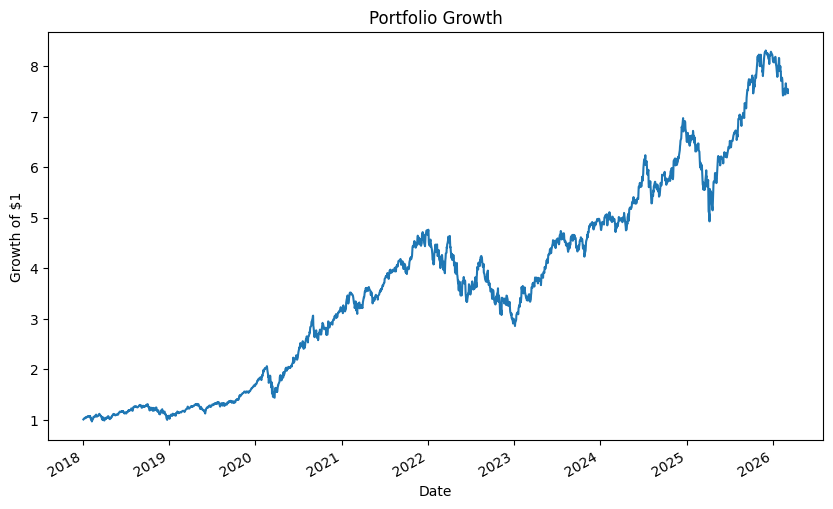

In [16]:
port_growth = portfolio_growth(port_rets)

port_growth.plot(figsize=(10, 6))
plt.title("Portfolio Growth")
plt.ylabel("Growth of $1")
plt.show()

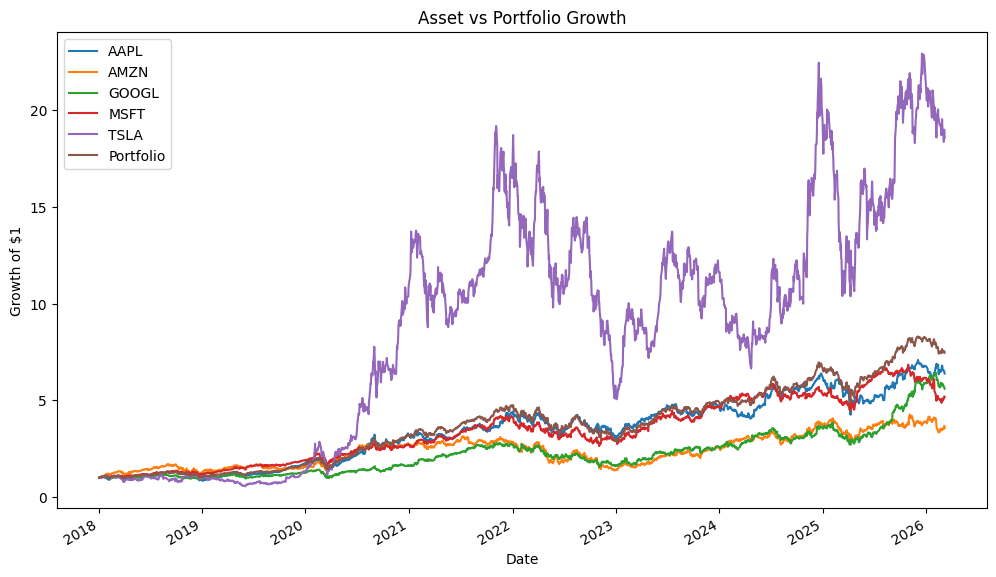

In [17]:
asset_growth = (1 + returns).cumprod()
asset_growth["Portfolio"] = port_growth

asset_growth.plot(figsize=(12, 7))
plt.title("Asset vs Portfolio Growth")
plt.ylabel("Growth of $1")
plt.show()

In [18]:
portfolios = {
    "Aggressive": {"AAPL":0.4, "MSFT":0.4, "GOOGL":0.2},
    "Balanced": {"AAPL":0.2, "MSFT":0.4, "GOOGL":0.4}
}
portfolio_returns_df = compare_portfolios(returns, portfolios)
compare_portfolios(returns, portfolios)

,Aggressive,Balanced
Date,,
2018-01-03,0.005204,0.008651
2018-01-04,0.006155,0.006003
2018-01-05,0.012165,0.012540
2018-01-08,-0.000371,0.001078
2018-01-09,-0.000572,-0.000804
...,...,...
2026-03-02,0.003373,-0.000397
2026-03-03,0.002016,0.000830
2026-03-04,-0.000904,-0.000268


In [20]:
portfolio_metrics_df = compare_portfolio_metrics(portfolio_returns_df)
portfolio_metrics_df

,Annual Return,Annual Volatility,Sharpe,Max Drawdown
Aggressive,0.258780,0.264872,0.976999,-0.338482
Balanced,0.255654,0.265324,0.963554,-0.368001
